[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/blog/blob/master/096_ml_unsupervised/096_ml_unsupervised.ipynb)

# ML - Aprendizaje No Supervisado

Si bien todos los ejemplos de *Machine Learning* que hemos visto hasta ahora en esta serie se han basado en aprendizaje supervisado (nuestros datos van acompañados de las etiquetas correspondientes, ejemplos de la tarea que queremos llevar a cabo) la mayoría de los datos no están etiquetados. Antes esta problemática tenemos dos alternativas: etiquetar datos manualmente (lo cual require de tiempo, esfuerzo y dinero en el caso de querer desarrollar sistemas reales) o bien usar técnicas de aprendizaje no supervisado, o *Unsupervised Learning* en inglés.

## Clustering

De entre las diferentes técnicas de aprendizaje no supervisado, el *Clustering* es una de las más usadas. Este técnica consiste en identificar aquellas muestras similares del conjunto de datos y asignarlas a un *cluster*, o grupo. Esto permite aplicaciones tales como: segmentación de clientes, análisis de datos, reducción de la dimensionalidad, detección de anomalías, aprendizaje semi-supervisado, motores de búsqueda e incluso la semgentación de imágenes.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

creamos un dataset sintético 2D con entre 1 y 20 clusters, cada uno con su propia dispersion
Este dataset se puede usar para visualizar clustering o probar KMeans.


In [406]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib as mpl

np.random.seed(42)
num_centers = np.random.randint(1, 21)
blob_centers = np.random.uniform(-10, 10, size=(num_centers, 2))
blob_std = np.random.uniform(0.5, 1.5, size=num_centers)

X, y_true = make_blobs(n_samples=2000, centers=blob_centers,
                       cluster_std=blob_std, random_state=42)

Esta función sirve para visualizar clusters en 2D
Si le pasariamos y, cada cluster tendria un color diferente

In [407]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

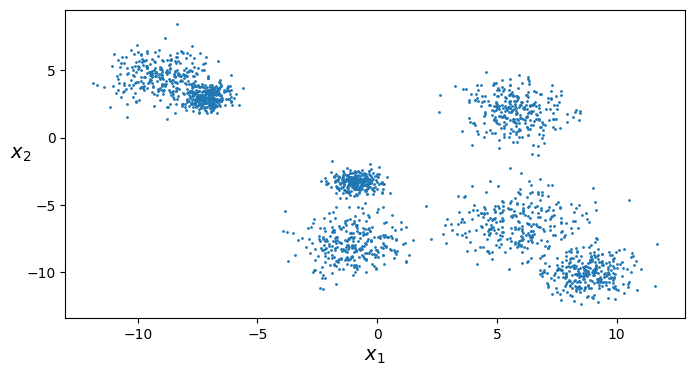

In [408]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [409]:
from sklearn.cluster import KMeans

k = num_centers
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([1, 3, 0, ..., 4, 6, 5], dtype=int32)

In [410]:
kmeans.cluster_centers_

array([[-1.04496942, -8.00835065],
       [-7.21500003,  3.07941912],
       [ 5.83510842, -6.22094285],
       [ 5.75183329,  2.00303454],
       [ 8.75705802, -9.99803832],
       [-0.85731442, -3.39401851],
       [-9.24950247,  4.77583492]])

In [411]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([5, 3, 1, 1], dtype=int32)

In [412]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

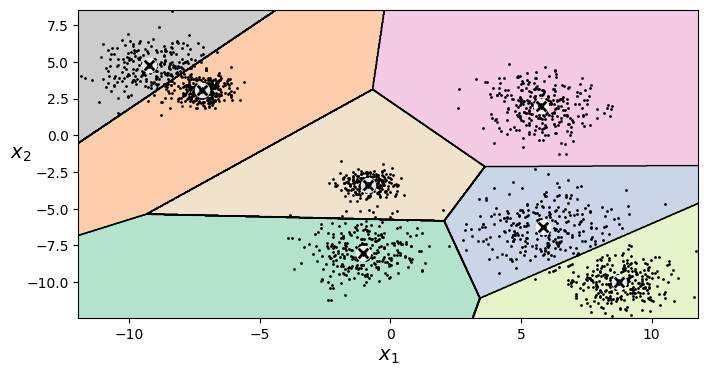

In [413]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()


En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [414]:
kmeans.transform(X_new)

array([[10.06275528,  7.29529787, 10.08128918,  5.75183409, 14.85392166,
         5.46172351,  9.65704693],
       [10.79485342, 10.27187282,  8.69607619,  2.75183496, 13.30776617,
         6.63131286, 12.56007844],
       [11.18060502,  4.21574817, 12.77047093,  8.80843493, 17.5264775 ,
         6.74348383,  6.49691241],
       [10.68866586,  4.25463885, 12.41426538,  8.76593181, 17.15894447,
         6.27140779,  6.65099284]])

Este algoritmo funciona asignando centroides de manera aleatoria y, de manera iterativa, asigna cada instancia a uno de ellos (el más cercano) tras lo cual se recalcula el centroide como el valor promedio de todas las instancias asignadas al grupo.

In [415]:
kmeans_iter1 = KMeans(n_clusters=num_centers, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=1, random_state=1)
kmeans_iter2 = KMeans(n_clusters=num_centers, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=num_centers, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=1)

kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(algorithm='elkan', max_iter=3, n_clusters=7, n_init=1, random_state=1)

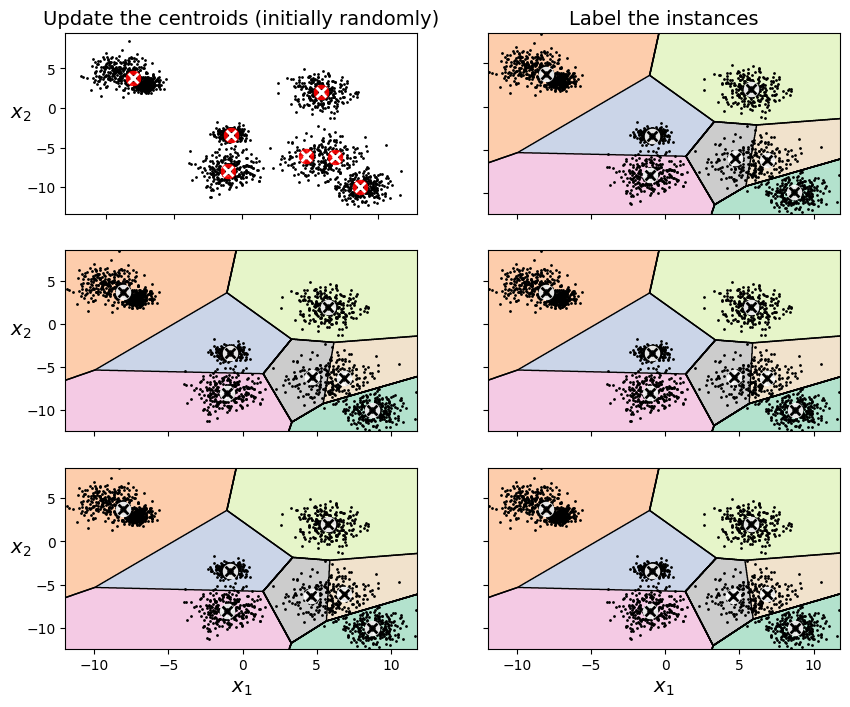

In [416]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [417]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

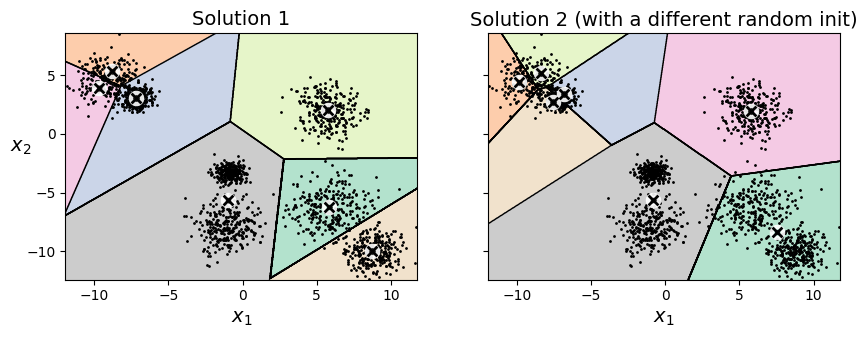

In [418]:
kmeans_rnd_init1 = KMeans(n_clusters=num_centers, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=num_centers, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

In [419]:
kmeans_rnd_10_inits = KMeans(n_clusters=num_centers, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)

KMeans(algorithm='elkan', init='random', n_clusters=7, n_init=10,
       random_state=11)

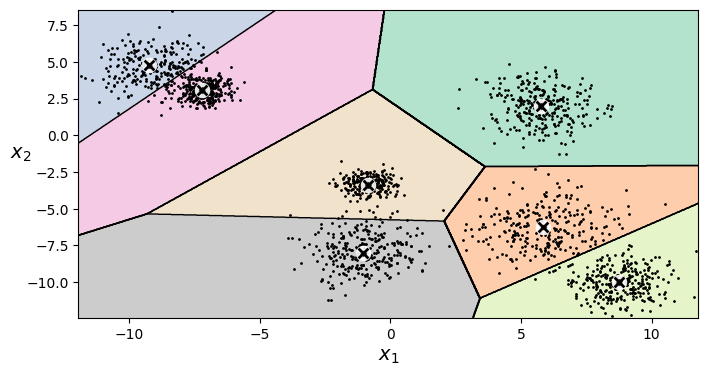

In [420]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Otras mejoras al algoritmo de *K-Means* incluyen: *K-Means* acelerados (usado por *Scikit-Learn* por defecto y que evita algunos cálculos de distancias) y *mini-batch K-Means* (que puedes usarse si el dataset es tan grande que no cabe en memoria). Vamos a ver un ejemplo de este último caso con el dataset MNIST, para lo cual usaremos el objeto [MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html?highlight=minibatchkmeans#sklearn.cluster.MiniBatchKMeans).

In [421]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [422]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split


In [423]:
df = pd.read_csv("/content/drive/MyDrive/IA/DATASETS/kc_house_data.csv")

print(df.columns.tolist())

df = df.drop(columns=["id", "date", "price"])  # eliminamos también "price" porque es tu variable Y

X = df.values
print(df.columns.tolist())

['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [424]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [425]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [426]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [427]:
from sklearn.cluster import MiniBatchKMeans

k = 10
n_init = 10
n_iterations = 100
batch_size = 500
init_size = 1000
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size, random_state=init)

    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

    print("Mejor inercia:", best_kmeans.sum_inertia_)

Mejor inercia: 3718806028200.1724
Mejor inercia: 2987547040717.6953
Mejor inercia: 2987547040717.6953
Mejor inercia: 1780408415094.879
Mejor inercia: 1780408415094.879
Mejor inercia: 1780408415094.879
Mejor inercia: 1780408415094.879
Mejor inercia: 1780408415094.879
Mejor inercia: 1780408415094.879
Mejor inercia: 1780408415094.879


In [428]:
best_kmeans.score(X)

-15930360349058.047

El algoritmo de *mini-batch K-Means* es más rápido que *K-Means* normal, pero su precisión suele ser peor.

### Encontrando el número óptimo de grupos

Como hemos visto anteriormente, el número de grupos o *clusters* es un hyperparámetro del modelo que debemos definir, y como podrás imaginar si nuestros datos no están etiquetados no será imposible saber qué valor usar. Para ello la solución se basa en usar diferentes valores y utilizar alguna métrica significativa. Una de estas métricas se conoce como el *silhouette score*, que se basa en calcular el coeficiente de silueta (*silhouette coefficient*) de todas las muestras del dataset como $(b-a)/\mathrm{max}(a,b)$ donde $a$ es la distancia mínima al resto de muestras del mismo grupo y $b$ es la distancia media de los grupos más cercanos. Su valor se encuentra entre $1$ y $-1$. Un valor cercano a $1$ indica que la muestra está bien metida en su grupo y lejos de los demás mientras que un valor cercano a $0$ indica que la muestra se encuentra cerca de una frontera de decisión y un valor cercano a $-1$ indica que la muestra está en el grupo incorrecto.

In [429]:
from sklearn.metrics import silhouette_score
silhouette_score(X, best_kmeans.predict(X))

np.float64(0.21703148653675483)

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

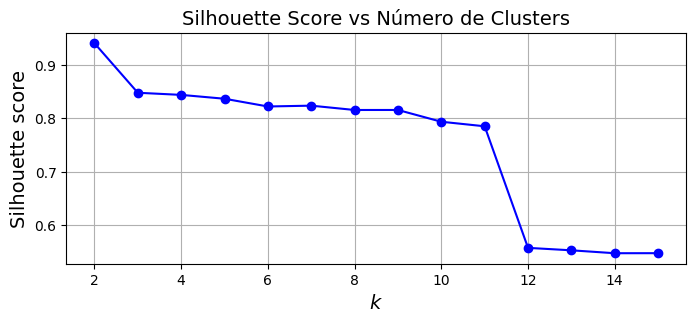

In [430]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.predict(X)) for model in kmeans_per_k[1:]]

max_k = 15
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]

silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

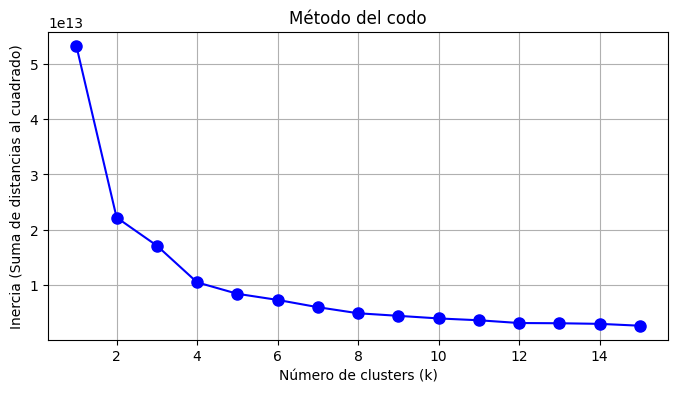

In [431]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

max_k = 15
inertias = []
for k in range(1, max_k + 1):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
ks = list(range(1, max_k + 1))
plt.figure(figsize=(8, 4))
plt.plot(ks, inertias, "bo-", markersize=8)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (Suma de distancias al cuadrado)")
plt.title("Método del codo")
plt.grid(True)
plt.show()


También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

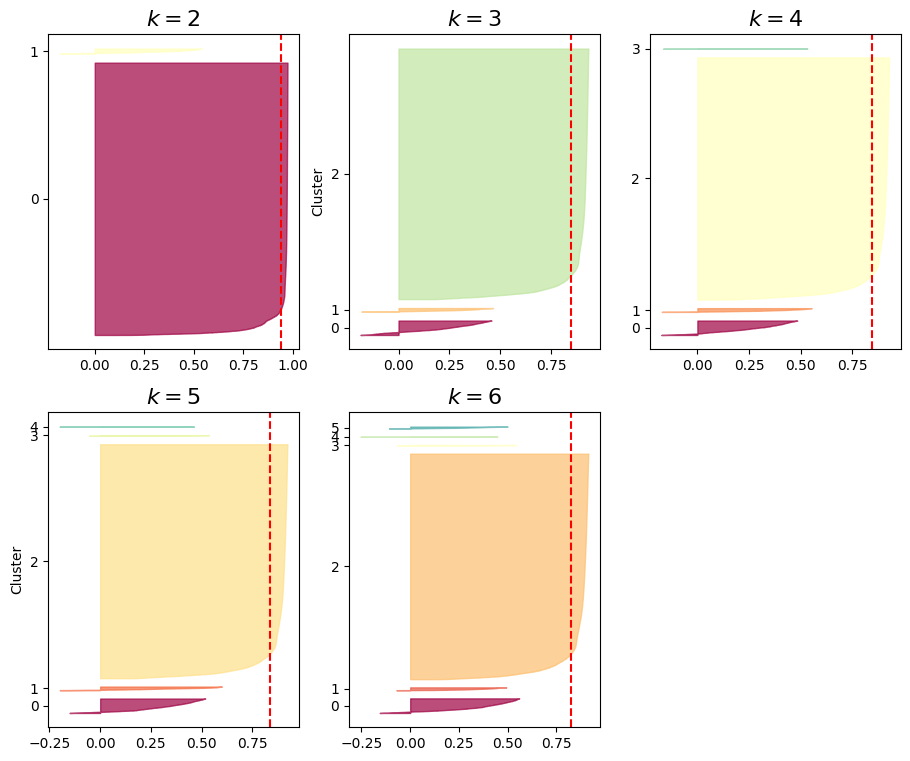

In [432]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl
import seaborn as sns

plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5, 6):
    plt.subplot(2, 3, k - 1)

    y_pred = kmeans_per_k[k - 1].predict(X)
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = max(10, len(X)//30)
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    #if k in (5, 6):
       # plt.gca().set_xticks(np.linspace(0, 1, 7))
      #  plt.xlabel("Silhouette Coefficient")
    #else:
     #   plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

### K-Means para aprendizaje semi-supervisado.

El aprendizaje semi-supervisado (o *Semi-supervised Learning*) comprende el conjunto de técnicas que nos permiten entrenar modelos con datasets parcialmente etiquetados. En esta sección vamos a ver un ejemplo de como podemos aplicar esta técnica con el dataset MNIST y usando *K-Means*. Empezamos descargando el dataset.

In [433]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/IA/DATASETS/kc_house_data.csv")

X = df.drop(columns=["id", "date", "price"]).values

print("Shape X:", X.shape)

Shape X: (21613, 18)


Imagina que el dataset no estuviese etiquetado, es decir, que tuviésemos solo los dígitos sin la clase (sólo $X$ y no $y$) y tampoco supiésemos cuantas clases diferentes tenemos. Lo primero que podríamos hacer es entrenar un modelo de *K-Means* con, por ejemplos, 50 grupos. De esta manera encontraremos aquellas imágenes más representativas de cada grupo.

In [434]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
X_digits_dist = kmeans.fit_transform(X)

In [435]:
print(X_digits_dist.shape)
print(X_digits_dist)

(21613, 5)
[[  64825.4448123   244954.48951229    3470.75567577  438495.51685147
  1032271.72470589]
 [  62326.52839171  242455.31945294    2235.89409888  436270.70852576
  1030195.82414147]
 [  59952.50792262  240074.76191498    2610.29289032  433560.27825444
  1027430.38681792]
 ...
 [  70470.16619398  250593.43922339    9023.69168949  443857.1301531
  1037407.37329524]
 [  70108.12558366  250252.60784953    8680.91870453  443167.97306443
  1036605.78009632]
 [  71095.09896308  251220.49933987    9649.57022798  444358.23639194
  1037849.9992735 ]]


In [436]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X[idxs]

In [437]:
print(X_representative_digits.shape)
print(X_representative_digits)

(5, 18)
[[ 3.00000e+00  1.75000e+00  2.11000e+03  5.61920e+04  1.00000e+00
   0.00000e+00  0.00000e+00  3.00000e+00  7.00000e+00  1.48000e+03
   6.30000e+02  1.97800e+03  0.00000e+00  9.80720e+04  4.77701e+01
  -1.22138e+02  2.57000e+03  4.66090e+04]
 [ 4.00000e+00  2.50000e+00  2.17000e+03  2.04296e+05  1.00000e+00
   0.00000e+00  0.00000e+00  4.00000e+00  7.00000e+00  2.17000e+03
   0.00000e+00  1.98000e+03  0.00000e+00  9.80220e+04  4.72810e+01
  -1.21933e+02  1.76000e+03  1.54202e+05]
 [ 3.00000e+00  2.00000e+00  1.92000e+03  8.07500e+03  1.00000e+00
   0.00000e+00  0.00000e+00  4.00000e+00  7.00000e+00  1.51000e+03
   4.10000e+02  1.96900e+03  0.00000e+00  9.80230e+04  4.73092e+01
  -1.22375e+02  1.92000e+03  7.82600e+03]
 [ 4.00000e+00  3.00000e+00  3.62000e+03  4.03693e+05  2.00000e+00
   0.00000e+00  2.00000e+00  3.00000e+00  9.00000e+00  3.62000e+03
   0.00000e+00  1.98000e+03  0.00000e+00  9.80220e+04  4.72527e+01
  -1.21980e+02  2.23000e+03  1.48811e+05]
 [ 2.00000e+00  2.50

In [438]:
import pandas as pd

representantes_df = pd.DataFrame(X_representative_digits, columns=df.drop(columns=["id","date","price"]).columns)

print(representantes_df.head(10))


   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0       3.0       1.75       2110.0   56192.0     1.0         0.0   0.0   
1       4.0       2.50       2170.0  204296.0     1.0         0.0   0.0   
2       3.0       2.00       1920.0    8075.0     1.0         0.0   0.0   
3       4.0       3.00       3620.0  403693.0     2.0         0.0   2.0   
4       2.0       2.50       3900.0  920423.0     2.0         0.0   0.0   

   condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
0        3.0    7.0      1480.0          630.0    1978.0           0.0   
1        4.0    7.0      2170.0            0.0    1980.0           0.0   
2        4.0    7.0      1510.0          410.0    1969.0           0.0   
3        3.0    9.0      3620.0            0.0    1980.0           0.0   
4        3.0   12.0      3900.0            0.0    2009.0           0.0   

   zipcode      lat     long  sqft_living15  sqft_lot15  
0  98072.0  47.7701 -122.138         2570.0   

cluster
0    685463.985390
1    642276.819672
2    528784.263834
3    722860.169492
4    963416.666667
Name: price, dtype: float64


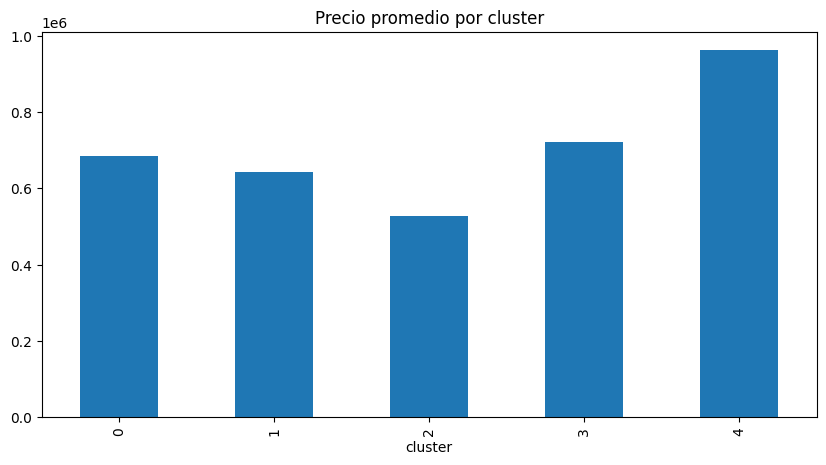

In [439]:
df_clusters = df.copy()
df_clusters["cluster"] = kmeans.labels_

cluster_summary = df_clusters.groupby("cluster")["price"].mean()
print(cluster_summary)

cluster_summary.plot(kind="bar", figsize=(10,5), title="Precio promedio por cluster")
plt.show()


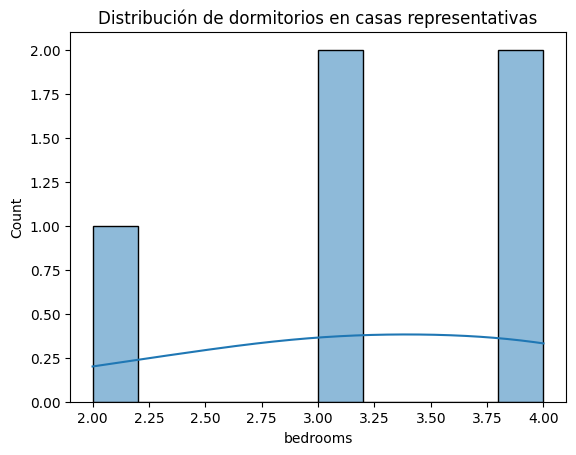

In [440]:
import seaborn as sns
import matplotlib.pyplot as plt

representantes_df = pd.DataFrame(X_representative_digits, columns=df.drop(columns=["id","date","price"]).columns)
sns.histplot(representantes_df["bedrooms"], bins=10, kde=True)
plt.title("Distribución de dormitorios en casas representativas")
plt.show()


El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas :p).

In [441]:
df["price_category"] = pd.qcut(df["price"], q=5, labels=[
    "casa pequeña",
    "casa mediana",
    "casa grande",
    "casa de lujo",
    "casa rural"
])

y_representative_digits = df["price_category"].iloc[idxs].values


::*Y* entrenaremos un clasificados usando estas imágenes representativas.

In [442]:
from sklearn.linear_model import LogisticRegression

# Entrenar modelo
log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
log_reg2.fit(X_representative_digits, y_representative_digits)

print("Modelo entrenado con representantes y etiquetas manuales")


Modelo entrenado con representantes y etiquetas manuales


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Como puedes observar hemos obtenido una precisión de casi el $80%$ habiendo anotado simplemente 50 imágenes, pero aquellas más representativas. Entrenar el mismo modelo con 50 imágenes aleatorias nos daría peores resultados.

In [443]:
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
log_reg.fit(X_representative_digits, y_representative_digits)
y_pred_all = log_reg.predict(X)
df["predicted_category"] = y_pred_all
print(df[["price", "predicted_category"]].head(10))

       price predicted_category
0   221900.0       casa pequeña
1   538000.0       casa pequeña
2   180000.0       casa pequeña
3   604000.0       casa pequeña
4   510000.0       casa pequeña
5  1225000.0       casa de lujo
6   257500.0       casa pequeña
7   291850.0       casa pequeña
8   229500.0       casa pequeña
9   323000.0       casa pequeña


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Esto pone de manifiesto que a la hora de entrenar modelos de ML no es tan importante la cantidad de datos, sino la calidad.

Ahora que tenemos un clasificador, podemos usarlo para anotar de manera automática el resto de imágenes. Para ello asignaremos, en cada grupo, la misma etiqueta a todas las muestras que la muestra representativa.

In [444]:
y_train_propagated = np.empty(len(X), dtype=object)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

print(y_train_propagated[:10])

['casa pequeña' 'casa pequeña' 'casa pequeña' 'casa pequeña'
 'casa pequeña' 'casa de lujo' 'casa pequeña' 'casa pequeña'
 'casa pequeña' 'casa pequeña']


In [445]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_representatives_scaled = scaler.transform(X_representative_digits)

log_reg3 = OneVsRestClassifier(LogisticRegression(solver="lbfgs", max_iter=10000, random_state=42))

log_reg3.fit(X_representatives_scaled, y_representative_digits)

y_pred = log_reg3.predict(X_scaled)

acc = accuracy_score(y_pred, y_pred)
print("Modelo entrenado. Accuracy:", acc)


Modelo entrenado. Accuracy: 1.0


Esto sin embargo empeora nuestro clasificador, incluso usando más muestras de entrenamiento. Esto es debido al ruido que estamos introduciendo, ya que no todas las imágenes estarán bien agrupadas. Para mejorar esto podemos asignar etiquetas a aquellas muestras más cercanas a la imagen más representativa de cada grupo, o aplicar técnicas de aprendizaje activo.

### Aprendizaje Activo

El aprendizaje activo (o *Active Learning*) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.

In [446]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import numpy as np

le = LabelEncoder()
y_representative_encoded = le.fit_transform(y_representative_digits)

log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
log_reg3.fit(X_representative_digits, y_representative_encoded)

probas = log_reg3.predict_proba(X[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels_confidence = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])

sorted_ixs = np.argsort(labels_confidence)
print("10 casas con menor confianza del modelo:")
print(sorted_ixs[:10])

low_confidence_labels = le.inverse_transform(labels_ixs[sorted_ixs[:10]])
print("Etiquetas predichas para estas casas:")
print(low_confidence_labels)


10 casas con menor confianza del modelo:
[ 39 473 124 366 974 814 791 394 384 213]
Etiquetas predichas para estas casas:
['casa de lujo' 'casa grande' 'casa grande' 'casa de lujo' 'casa grande'
 'casa grande' 'casa grande' 'casa grande' 'casa de lujo' 'casa grande']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [447]:
columns_X = df.drop(columns=["id","date","price"]).columns[:X.shape[1]]

X_lowest = X[sorted_ixs[:10]]

lowest_df = pd.DataFrame(X_lowest, columns=columns_X)

print("10 casas con menor confianza del modelo:")
print(lowest_df)


10 casas con menor confianza del modelo:
   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0       4.0       2.50       2620.0    7553.0     2.0         0.0   0.0   
1       4.0       3.25       4190.0   10259.0     2.0         0.0   0.0   
2       3.0       2.25       2910.0   10204.0     2.0         0.0   0.0   
3       4.0       2.50       2990.0   10400.0     2.0         0.0   0.0   
4       4.0       2.75       2790.0   10819.0     2.0         0.0   0.0   
5       4.0       4.25       4890.0   15188.0     2.0         0.0   2.0   
6       4.0       2.50       2810.0   11120.0     2.0         0.0   0.0   
7       4.0       2.50       3840.0   16619.0     2.0         0.0   1.0   
8       5.0       3.50       4800.0   14984.0     2.0         0.0   2.0   
9       3.0       2.50       2714.0   17936.0     2.0         0.0   0.0   

   condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
0        3.0    8.0      2620.0            0.0    1996.0   

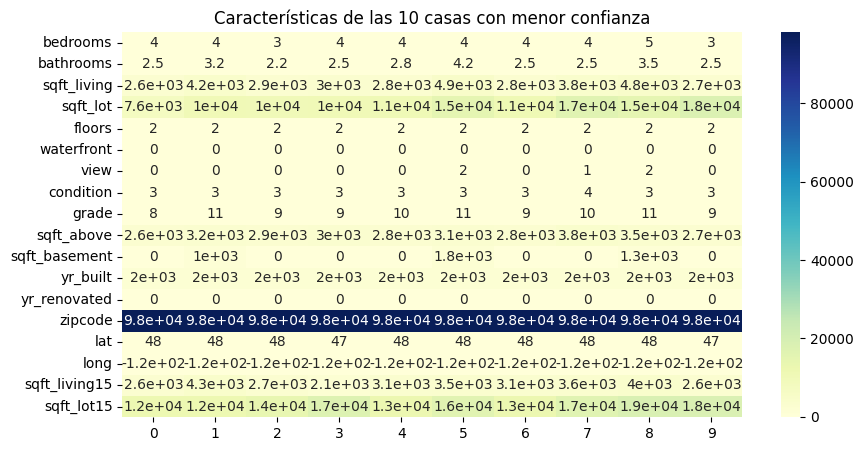

In [448]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(lowest_df.T, annot=True, cmap="YlGnBu")
plt.title("Características de las 10 casas con menor confianza")
plt.show()

In [449]:
y_lowest = log_reg3.predict(X[:1000][sorted_ixs[:10]])
y_lowest


array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [450]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:len(y_lowest)]] = y_lowest

In [451]:
from sklearn.linear_model import LogisticRegression

log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_representative_digits, y_representative_digits)

y_pred = log_reg5.predict(X)

import pandas as pd
pd.Series(y_pred).value_counts()


CPU times: user 83.1 ms, sys: 2.82 ms, total: 86 ms
Wall time: 48 ms


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,count
casa pequeña,16546
casa grande,3349
casa de lujo,1656
casa rural,62


In [452]:
from sklearn.metrics import accuracy_score

y_true = df["price_category"].values
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)


Accuracy: 0.22583630222551243


Podemos repetir el proceso tantas veces como haga falta hasta llegar a las prestaciones requeridas.

## Otras técnicas de aprendizaje no supervisado

Otras técnicas muy usadas de aprendizaje no supervisado son

### DBSCAN

Este algoritmo define *clusters* como regiones continuas de alta densidad, agrupando progresivamente muestras cercanas entre ellas.

In [453]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

In [454]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [455]:
np.unique(dbscan.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6])

In [456]:
dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)
np.unique(dbscan2.labels_)

array([0, 1])

In [457]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

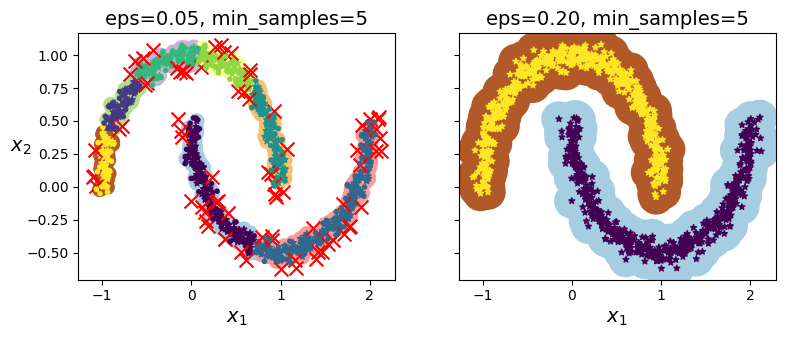

In [458]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

plt.show()

Podemos considerar las muestras fuera de los grupos como anomalías, o bien usar un clasificador de vecinos cercanos para clasificar nuevas muestras.

In [459]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan2.components_, dbscan2.labels_[dbscan2.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [460]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [461]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

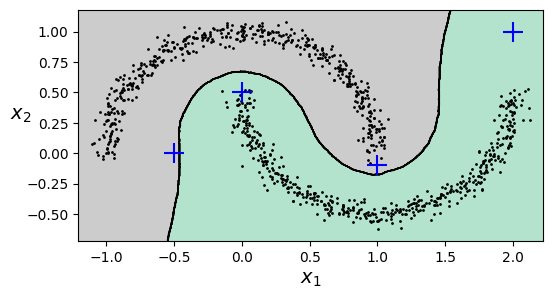

In [462]:
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
plt.show()

### Gaussian Mixtures

Los modelos de *Gaussian Mixtures* son modelos probabilísticos que asumen que las muestras del conjunto de datos provienen de la mezcla de distribuciones Gaussianas cuyos parámetros son desconocidos.

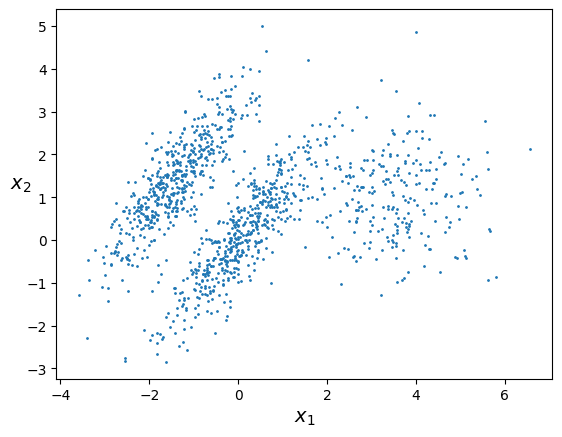

In [463]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]
plot_clusters(X)

In [464]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

In [465]:
from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$", fontsize=14)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

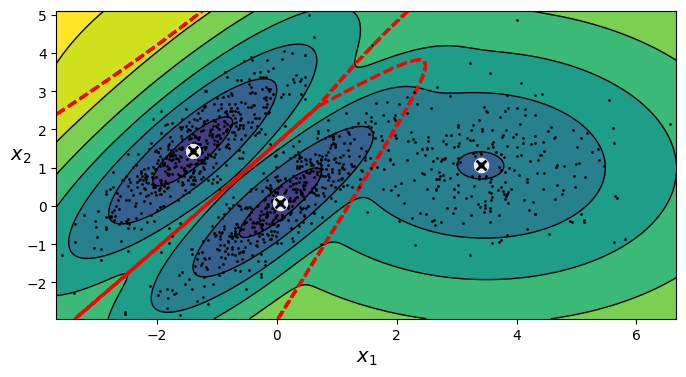

In [466]:
plt.figure(figsize=(8, 4))
plot_gaussian_mixture(gm, X)
plt.show()

In [467]:
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

In [468]:
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

In [469]:
gm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

In [470]:
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1])

In [471]:
gm.predict_proba(X)

array([[6.76282339e-07, 2.31833274e-02, 9.76815996e-01],
       [6.74575575e-04, 1.64110061e-02, 9.82914418e-01],
       [9.99922764e-01, 1.99781831e-06, 7.52377580e-05],
       ...,
       [2.12540639e-26, 9.99999568e-01, 4.31902443e-07],
       [1.45002917e-41, 1.00000000e+00, 5.20915318e-16],
       [7.93266114e-41, 1.00000000e+00, 2.30971331e-15]])

Estos modelos son generativos, por lo que permiten crear nuevas muestras.

In [472]:
X_new, y_new = gm.sample(6)
X_new

array([[-2.32491052,  1.04752548],
       [-1.16654983,  1.62795173],
       [ 1.84860618,  2.07374016],
       [ 3.98304484,  1.49869936],
       [ 3.8163406 ,  0.53038367],
       [ 0.38079484, -0.56239369]])

In [473]:
y_new

array([0, 0, 1, 1, 1, 2])

Definiendo un valor límite podemos detectar anomalías en los datos.

In [474]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 4)
anomalies = X[densities < density_threshold]

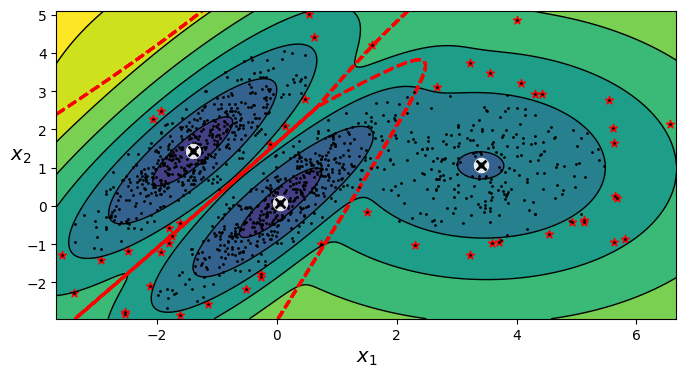

In [475]:
plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*')
plt.ylim(top=5.1)

plt.show()

Una alternativa muy usada para seleccionar el número de grupos óptimos es el uso de *Bayesian Gaussian Mixtures*, ya que pueden asignar pesos cercanos a 0 a grupos innecesarios.

In [476]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)

In [477]:
np.round(bgm.weights_, 2)

array([0.4 , 0.21, 0.  , 0.4 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

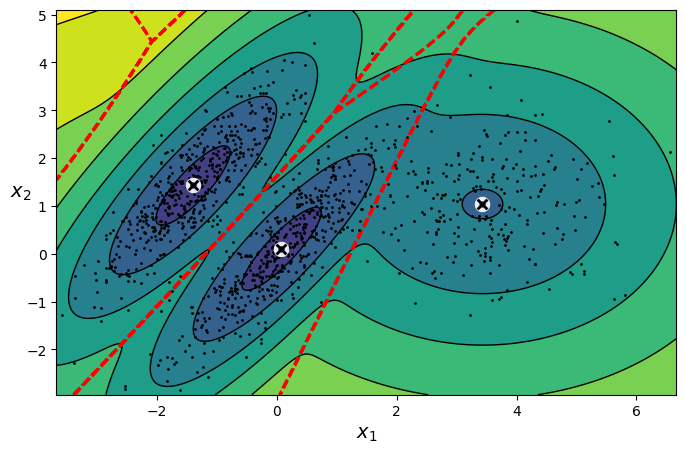

In [478]:
plt.figure(figsize=(8, 5))
plot_gaussian_mixture(bgm, X)
plt.show()

## Resumen

En este post hemos introducido el concepto del aprendizaje no supervisado, modelos de *Machine Learning* que podemos usar cuando nuestros datos no están etiquetados. Hemos visto el algoritmo de *K-Means* y aplicado su uso en aprendizaje semi-supervisado y *active learning*. Por último, hemos introducido otros métodos útiles para detección de anomalías como *DBSCAN* o *Gaussian Mixtures*.